In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [70]:
data = pd.read_csv('store_customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')


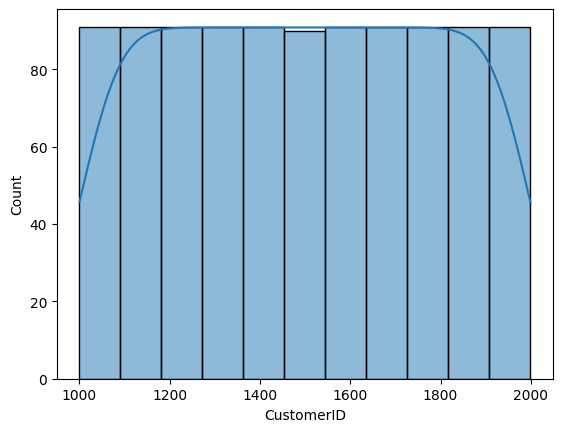

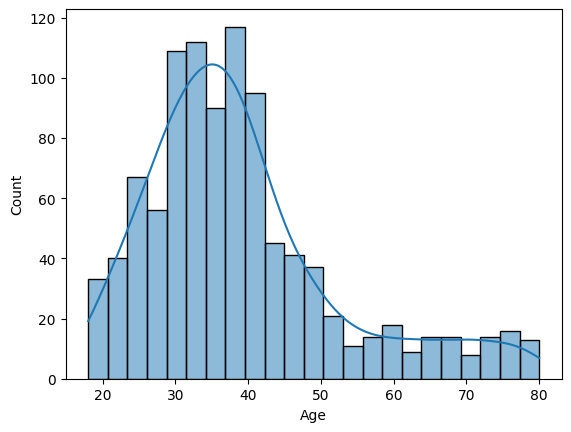

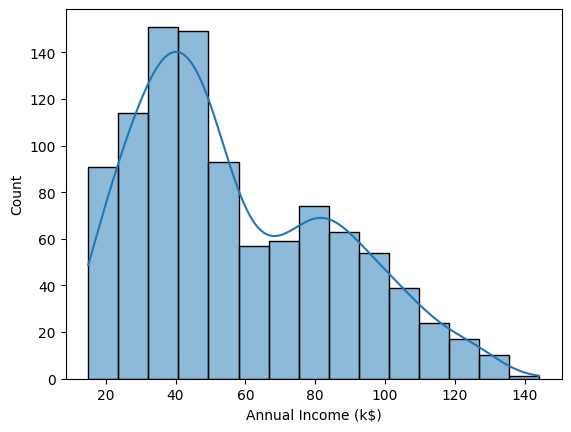

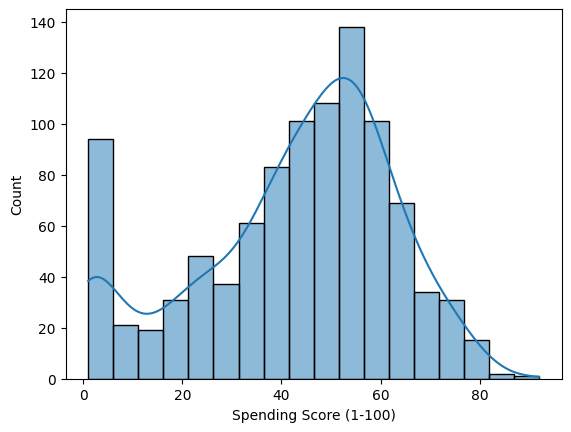

In [72]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
print(numeric_cols)
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

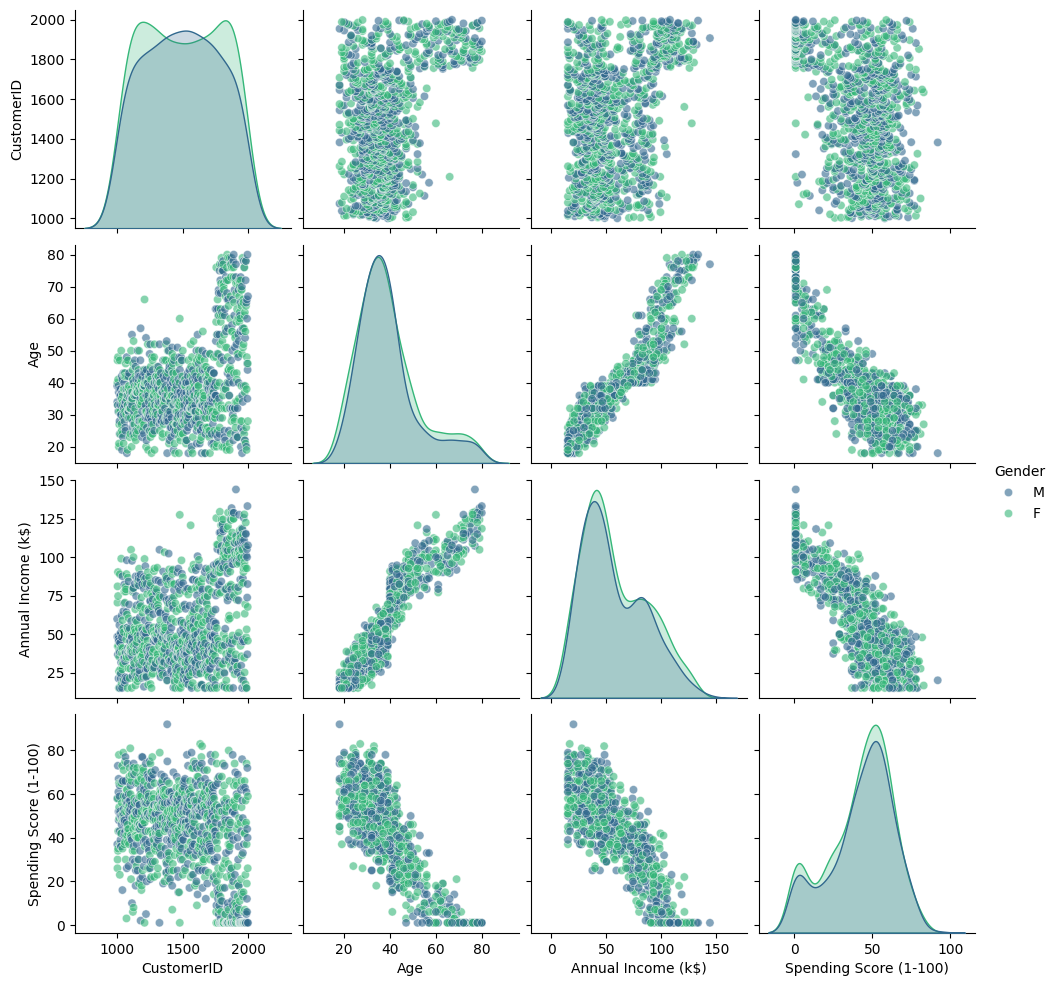

In [73]:
sns.pairplot(
    data, 
    hue='Gender', 
    vars=['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.show()

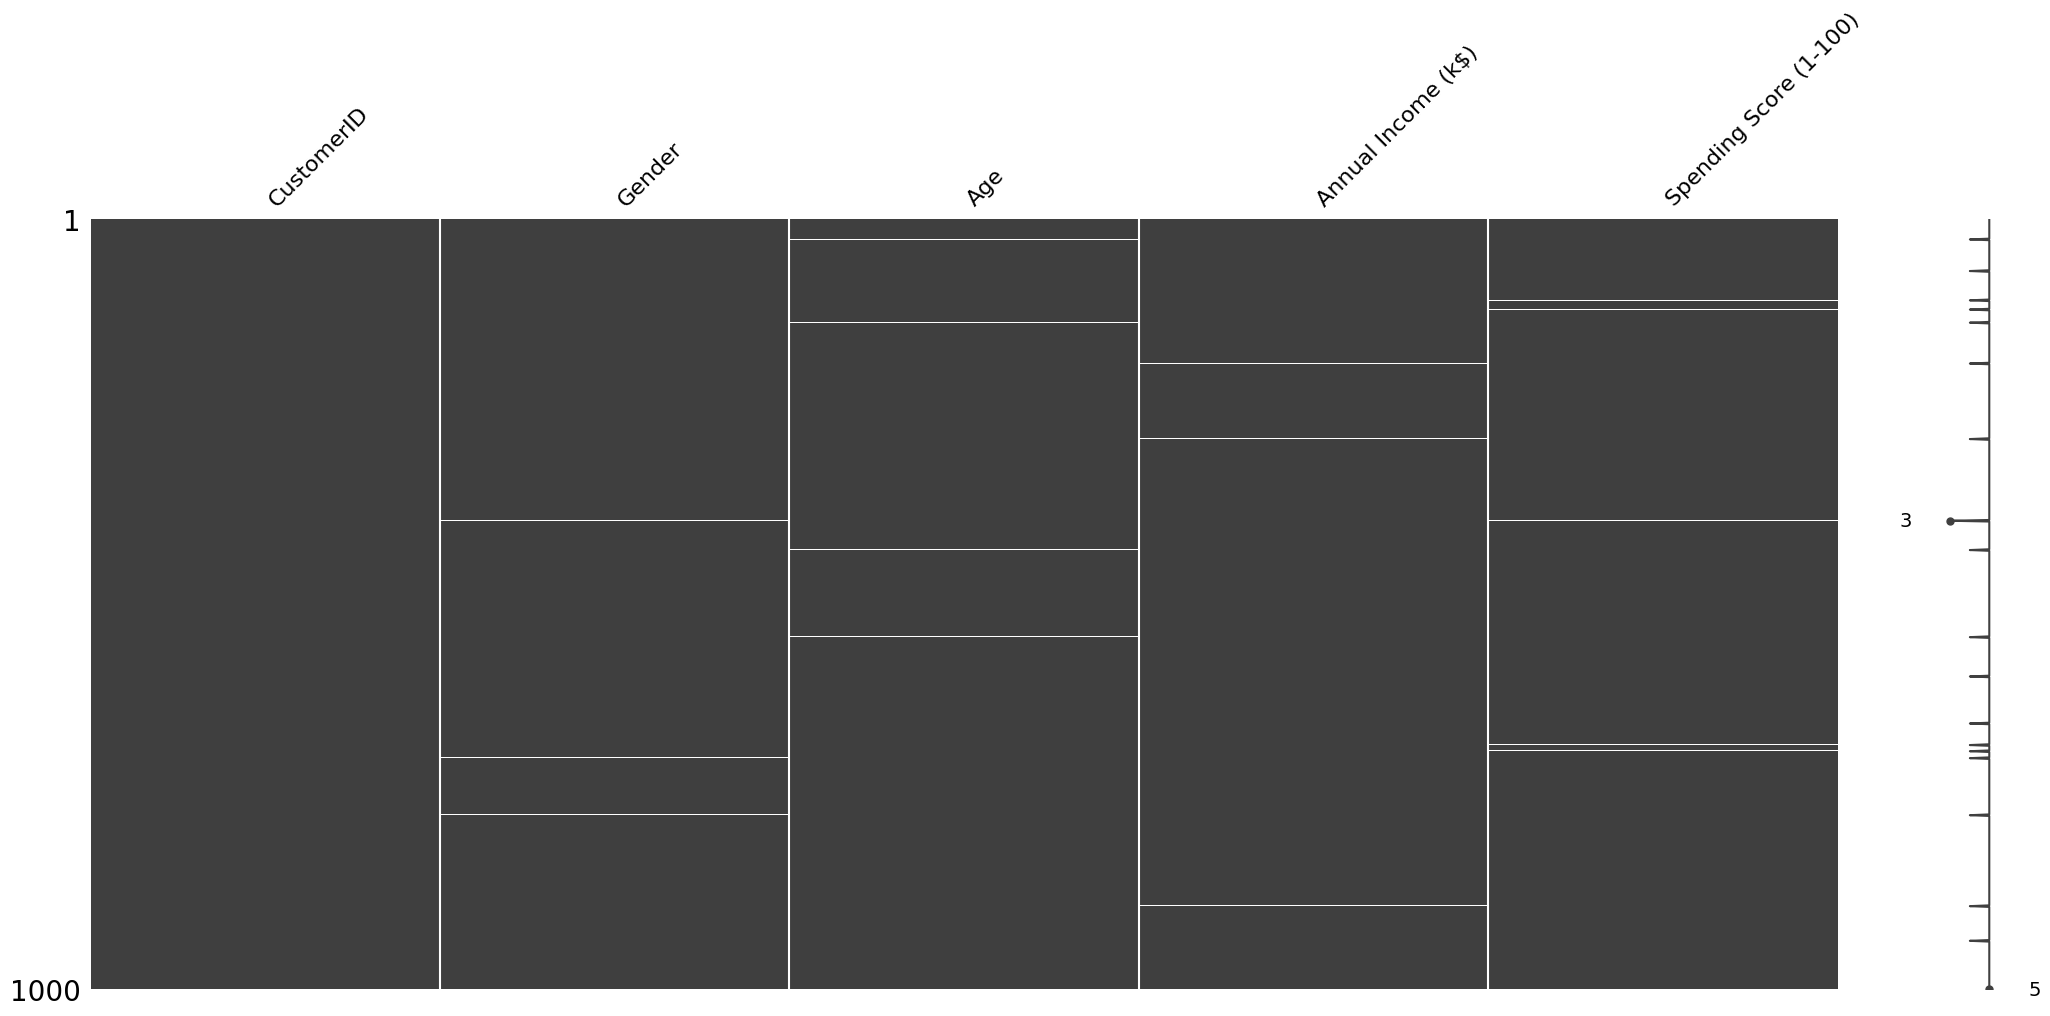

In [74]:
mnso.matrix(data)
plt.show()

In [75]:
nums = ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for num in nums:
    data[num] = data[num].fillna(data[num].median())
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

In [76]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  1000 non-null   str    
 2   Age                     1000 non-null   float64
 3   Annual Income (k$)      1000 non-null   float64
 4   Spending Score (1-100)  1000 non-null   float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [77]:
cat_col = [col for col in data.columns if data[col].dtype == 'str'] 
data_1 = pd.get_dummies(data,columns = cat_col, drop_first = True) 
data_1.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_M
0,1000,39.0,59.9,58.0,True
1,1001,34.0,48.4,37.0,True
2,1002,40.0,70.5,26.0,False
3,1003,47.0,81.1,30.0,False
4,1004,33.0,42.1,58.0,False


In [78]:
bool_cols = ['Gender_M']
data_1[bool_cols] = data_1[bool_cols].astype(int)
data_1.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_M
0,1000,39.0,59.9,58.0,1
1,1001,34.0,48.4,37.0,1
2,1002,40.0,70.5,26.0,0
3,1003,47.0,81.1,30.0,0
4,1004,33.0,42.1,58.0,0


In [79]:
X = data_1[['Annual Income (k$)',	'Spending Score (1-100)']]

In [80]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Elbow Method

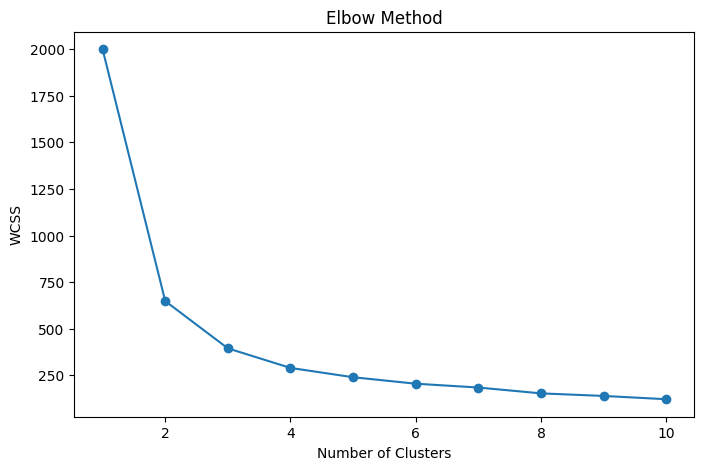

In [81]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [82]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

In [83]:
data_1['Cluster'] = y_kmeans

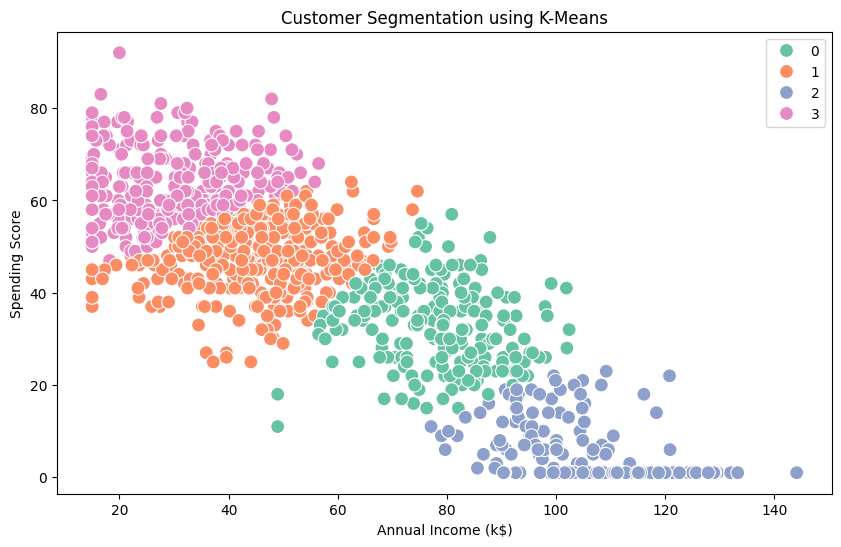

In [84]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=data_1['Annual Income (k$)'],
    y=data_1['Spending Score (1-100)'],
    hue=data_1['Cluster'],
    palette='Set2',
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [85]:
db = DBSCAN(eps=0.3, min_samples=10)

In [86]:
db_cluster = db.fit_predict(X)

In [87]:
data_2 = data_1.copy()

In [88]:
data_2['Cluster'] = db_cluster

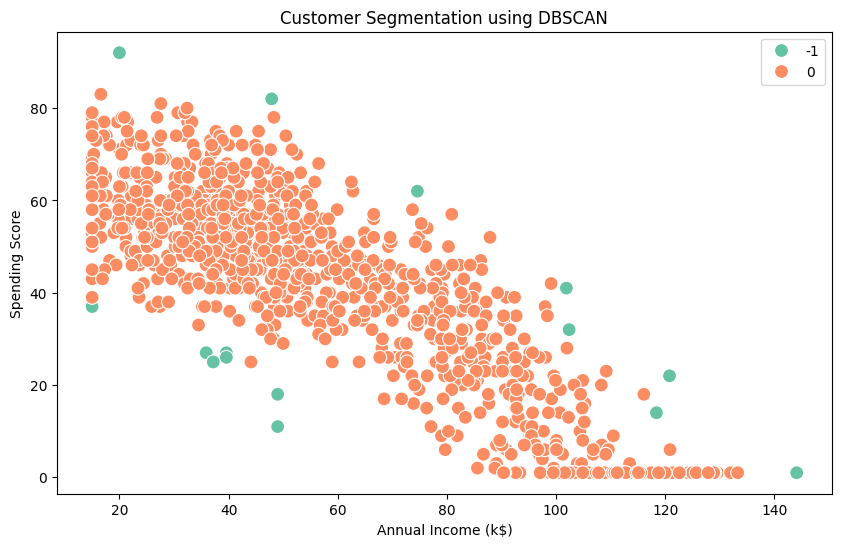

In [89]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=data_2['Annual Income (k$)'],
    y=data_2['Spending Score (1-100)'],
    hue=data_2['Cluster'],
    palette='Set2',
    s=100
)

plt.title("Customer Segmentation using DBSCAN")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()